1. Take a 6x6 NumPy array apply convolution operation of the array. Use zero pading and consider a 3x3 mask/kernel for convolution (with and without built in function). Show both input and output array NumPy array into an image and show them side by side in a subplot with a title

In [ ]:
# In Lab (6x6) numpy array convolution, madam's personal pruning method

import numpy as np


img = np.array([
    [1, 8, 8, 0, 7],
    [4, 7, 9, 5, 7],
    [5, 4, 6, 8, 6],
    [4, 2, 0, 1, 5],
    [0, 1, 0, 2, 0]
])

k = np.array([
    [1, 1, 1],
    [1, 1, 1],
    [1, 1, 1]
]) / 9

img = np.pad(img, 1, "constant", constant_values=0)

out = img.copy()

for i in range(1, img.shape[0]-1):
  for j in range(1, img.shape[1]-1):
    out[i, j] = round(np.sum(img[i-1:i+2, j-1:j+2] * k))

out = out[1:out.shape[0]-1, 1:out.shape[1]-1]

print(out)

[[2 4 4 4 2]
 [3 6 6 6 4]
 [3 5 5 5 4]
 [2 2 3 3 2]
 [1 1 1 1 1]]


Input:
 [[1 8 8 0 7 3]
 [4 7 9 5 7 2]
 [5 4 6 8 6 1]
 [4 2 0 1 5 9]
 [0 1 0 2 0 4]
 [3 6 2 7 1 8]]

Output:
 [[2 4 4 4 3 2]
 [3 6 6 6 4 3]
 [3 5 5 5 5 3]
 [2 2 3 3 4 3]
 [2 2 2 2 4 3]
 [1 1 2 1 2 1]]


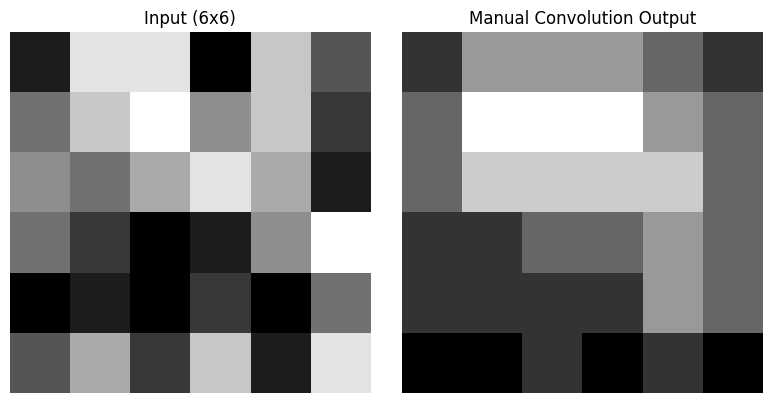

In [ ]:
# (6x6) Convolution. With Numpy function for pruning
import numpy as np
import matplotlib.pyplot as plt

# 1. 6x6 input
img = np.array([
    [1, 8, 8, 0, 7, 3],
    [4, 7, 9, 5, 7, 2],
    [5, 4, 6, 8, 6, 1],
    [4, 2, 0, 1, 5, 9],
    [0, 1, 0, 2, 0, 4],
    [3, 6, 2, 7, 1, 8]
])

# 2. 3x3 averaging kernel
k = np.array([
    [1, 1, 1],
    [1, 1, 1],
    [1, 1, 1]
]) / 9

# ==================
# Manual Convolution
# ==================
padded = np.pad(img, 1, "constant", constant_values=0)
out = padded.copy()

for i in range(1, padded.shape[0] - 1):
    for j in range(1, padded.shape[1] - 1):
        out[i, j] = round(np.sum(padded[i-1:i+2, j-1:j+2] * k))

# remove padding
out = out[1:-1, 1:-1]

# ============
# Show arrays
# ============
print("Input:\n", img)
print("\nOutput:\n", out)

# =================
# Plot side by side
# =================
plt.figure(figsize=(8, 4))

plt.subplot(1, 2, 1)
plt.imshow(img, cmap='gray')
plt.title("Input (6x6)")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(out, cmap='gray')
plt.title("Manual Convolution Output")
plt.axis('off')

plt.tight_layout()
plt.show()

2. Take an 8-bit grayscale image and apply smoothing operation by using mean filter (with and without built in image smoothing function). Show both input and output image side by side in a subplot with a title.

In [ ]:
# Mean Filter (In Lab) (row=3,col=3)/9
import cv2
import numpy as np

image = cv2.imread('./a.jpg')
image_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

k = np.ones((3, 3)) / 9

# pad the correct image
img = np.pad(image_gray, 1, mode="constant", constant_values=0)

out = np.zeros_like(image_gray)

for i in range(1,image_gray.shape[0]-1):
    for j in range(1,image_gray.shape[1]-1):
        region = img[i-1:i+2, j-1:j+2]
        out[i, j] = np.sum(region * k)

out = out[1:out.shape[0]-1, 1:out.shape[1]-1]

print(out)

[[ 70 105 105 ...  84  94 104]
 [105 158 158 ... 125 134 142]
 [105 158 158 ... 120 116 111]
 ...
 [ 36  52  52 ...  56  57  59]
 [ 34  49  50 ...  56  60  68]
 [ 32  46  49 ...  56  65  77]]


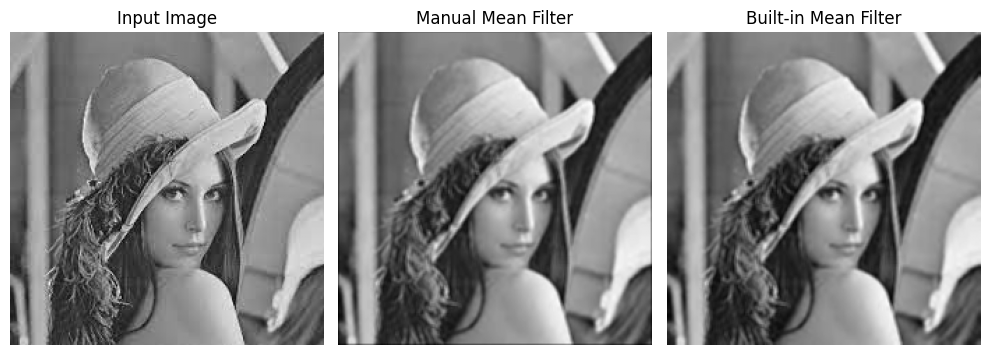

In [2]:
# Mean Filter (With/Without Built in Function)
import cv2
import numpy as np
import matplotlib.pyplot as plt

image = cv2.imread('./a.jpg')
image_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

k = np.ones((3, 3)) / 9

# =========================
# Manual Mean Filtering 
# =========================
padded = np.pad(image_gray, 1, mode="constant", constant_values=0)
manual_out = np.zeros_like(image_gray)

for i in range(1, padded.shape[0] - 1):
    for j in range(1, padded.shape[1] - 1):
        region = padded[i-1:i+2, j-1:j+2]
        manual_out[i-1, j-1] = np.sum(region * k)

# Clip to 8-bit range
manual_out = np.clip(manual_out, 0, 255).astype(np.uint8)

# =========================
# Built-in Mean Filter
# =========================
builtin_out = cv2.blur(image_gray, (3, 3))

# =========================
# Plot side by side
# =========================
plt.figure(figsize=(10, 4))

plt.subplot(1, 3, 1)
plt.imshow(image_gray, cmap='gray')
plt.title("Input Image")
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(manual_out, cmap='gray')
plt.title("Manual Mean Filter")
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(builtin_out, cmap='gray')
plt.title("Built-in Mean Filter")
plt.axis('off')

plt.tight_layout()
plt.show()

3. Take an 8-bit grayscale and apply smoothing operation by using weighted averaging filter (with and without built in smoothing function). Show both input and output image side by side in a subplot with a title)

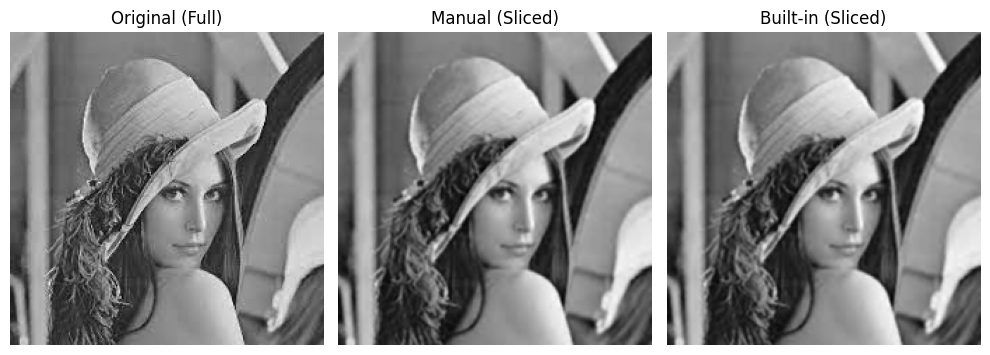

In [3]:
# Gaussian Filter ( Weighted Average )
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Read grayscale image
image = cv2.imread('./a.jpg')
image_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# Weighted kernel (Gaussian-like)
k = np.array([
    [1, 2, 1],
    [2, 4, 2],
    [1, 2, 1]
]) / 16

# =========================
# Manual Weighted Filtering (No Padding)
# =========================
h, w = image_gray.shape
# Create output buffer
manual_out = np.zeros_like(image_gray, dtype=float)

# Slide the kernel
for i in range(1, h - 1):
    for j in range(1, w - 1):
        # Extract 3x3 region
        region = image_gray[i-1:i+2, j-1:j+2]
        # Element-wise multiplication and sum
        manual_out[i, j] = np.sum(region * k)

# Remove the empty 1-pixel border caused by the kernel size
manual_out_final = manual_out[1:h-1, 1:w-1].astype(np.uint8)

# =========================
# Built-in Weighted Filter
# =========================
# We apply the built-in and slice it similarly to match dimensions for comparison
builtin_out = cv2.GaussianBlur(image_gray, (3, 3), 0)
builtin_out_final = builtin_out[1:h-1, 1:w-1]

# =========================
# Plotting
# =========================
plt.figure(figsize=(10, 4))

plt.subplot(1, 3, 1)
plt.imshow(image_gray, cmap='gray')
plt.title("Original (Full)")
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(manual_out_final, cmap='gray')
plt.title("Manual (Sliced)")
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(builtin_out_final, cmap='gray')
plt.title("Built-in (Sliced)")
plt.axis('off')

plt.tight_layout()
plt.show()

4. Take an 8-bit grayscale image and apply smoothing operation by using gaussian filter (with and without)

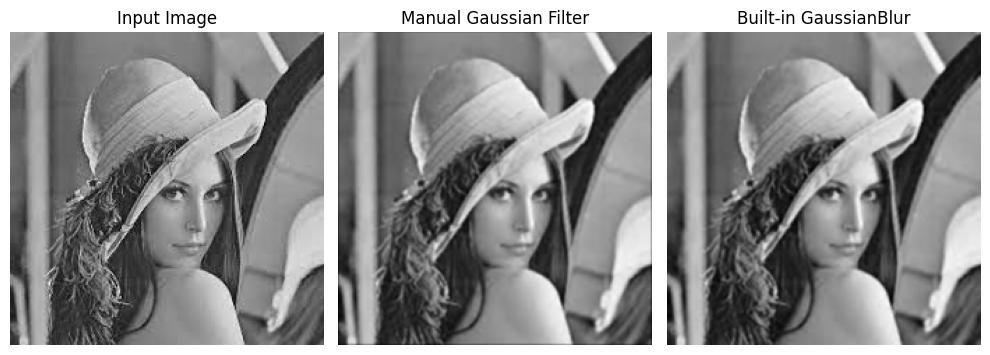

In [ ]:
# Gaussian (Filter Ops) (again?)
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Read grayscale image
image = cv2.imread('./a.jpg')
image_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# Gaussian kernel
k = np.array([
    [1, 2, 1],
    [2, 4, 2],
    [1, 2, 1]
]) / 16

# =========================
# Manual Gaussian Filtering
# =========================
padded = np.pad(image_gray, 1, mode="constant", constant_values=0)
manual_out = np.zeros_like(image_gray, dtype=np.float32)

for i in range(1, padded.shape[0] - 1):
    for j in range(1, padded.shape[1] - 1):
        region = padded[i-1:i+2, j-1:j+2]
        manual_out[i-1, j-1] = np.sum(region * k)

manual_out = np.clip(manual_out, 0, 255).astype(np.uint8)

# =========================
# Built-in Gaussian Filter
# =========================
builtin_out = cv2.GaussianBlur(image_gray, (3, 3), 0)

# =========================
# Plot results
# =========================
plt.figure(figsize=(10, 4))

plt.subplot(1, 3, 1)
plt.imshow(image_gray, cmap='gray')
plt.title("Input Image")
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(manual_out, cmap='gray')
plt.title("Manual Gaussian Filter")
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(builtin_out, cmap='gray')
plt.title("Built-in GaussianBlur")
plt.axis('off')

plt.tight_layout()
plt.show()